### Import Dependencies

In [ ]:
%pip install google_play_scraper

In [54]:
# Masukan Library yang dibutuhkan
from google_play_scraper import app
import pandas as pd
import numpy as np
from google_play_scraper import reviews, Sort
import os
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import MaxNLocator
import calendar
from textblob import TextBlob



### Scrapping App Comments

In [25]:
# Android App review scraping from Google Play
# App link: https://play.google.com/store/apps/details?gl=GB&hl=en-GB&id=com.mobile.legends

app_id = 'com.mobile.legends'

# Inisialisasi folder
folder = "data_scrap_mlbb"
os.makedirs(folder, exist_ok=True)

# Mengambil 5000 ulasan terbaru tanpa filter rating
result, _ = reviews(
    app_id,
    lang='en',
    sort=Sort.NEWEST,
    count=1000000
)

df = pd.DataFrame(result)

# Simpan ke satu file CSV utama
filename = f"{folder}/mlbb_reviews_all_1000000.csv"
df.to_csv(filename, index=False)

print(f"Berhasil mengamankan {len(df)} ulasan terbaru di {filename}")


Berhasil mengamankan 1000000 ulasan terbaru di data_scrap_mlbb/mlbb_reviews_all_1000000.csv


### Exploratory Data Analysis

In [26]:
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,8df38ed8-5ffe-4221-ac11-53ad0f7883c0,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,iloveit that's it,5,0,2.1.47.11491,2026-04-13 14:04:49,None,NaT,2.1.47.11491
1,5fc1842c-9f43-4f57-9a25-9543a459c8c1,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,may team is very nood pls ban them,1,0,2.1.61.11705,2026-04-13 14:04:40,None,NaT,2.1.61.11705
2,1eed7942-583f-48dc-8ac5-301f407b138e,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Just focus on releasing skins and no existing ...,1,0,2.1.61.11705,2026-04-13 14:03:57,None,NaT,2.1.61.11705
3,5acde99a-6bc7-4401-ac80-068a6e66f60a,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good gamee for holiday,5,0,2.1.47.11491,2026-04-13 14:02:44,None,NaT,2.1.47.11491
4,08c96811-447b-4f84-92d5-be00a1093a06,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,this game is good bro pls monton add some whit...,5,0,2.1.61.11705,2026-04-13 14:00:36,None,NaT,2.1.61.11705


In [27]:
df.describe()

,score,thumbsUpCount,at,repliedAt
count,1000000.000000,1000000.000000,1000000,797
mean,3.335783,2.686963,2024-06-23 07:25:21.701409536,2020-05-12 08:02:04.775407360
min,1.000000,0.000000,2023-02-03 17:00:56,2017-03-29 11:33:09
25%,1.000000,0.000000,2023-11-09 05:40:57.750000128,2018-04-16 12:24:57
50%,5.000000,0.000000,2024-06-05 04:48:34,2019-11-04 09:44:14
75%,5.000000,0.000000,2025-03-07 23:11:08.500000,2022-06-09 17:17:32
max,5.000000,44136.000000,2026-04-13 14:04:49,2026-04-09 10:03:25
std,1.865742,131.866424,NaN,NaN


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   reviewId              1000000 non-null  object        
 1   userName              1000000 non-null  object        
 2   userImage             1000000 non-null  object        
 3   content               999955 non-null   object        
 4   score                 1000000 non-null  int64         
 5   thumbsUpCount         1000000 non-null  int64         
 6   reviewCreatedVersion  750089 non-null   object        
 7   at                    1000000 non-null  datetime64[ns]
 8   replyContent          797 non-null      object        
 9   repliedAt             797 non-null      datetime64[ns]
 10  appVersion            750089 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 83.9+ MB


In [41]:
# Cek jumlah tiap skornya
count = df['score'].value_counts()
df_count = pd.DataFrame(count)
df_count

,count
score,
5,515867
1,360580
4,56581
3,35600
2,31372


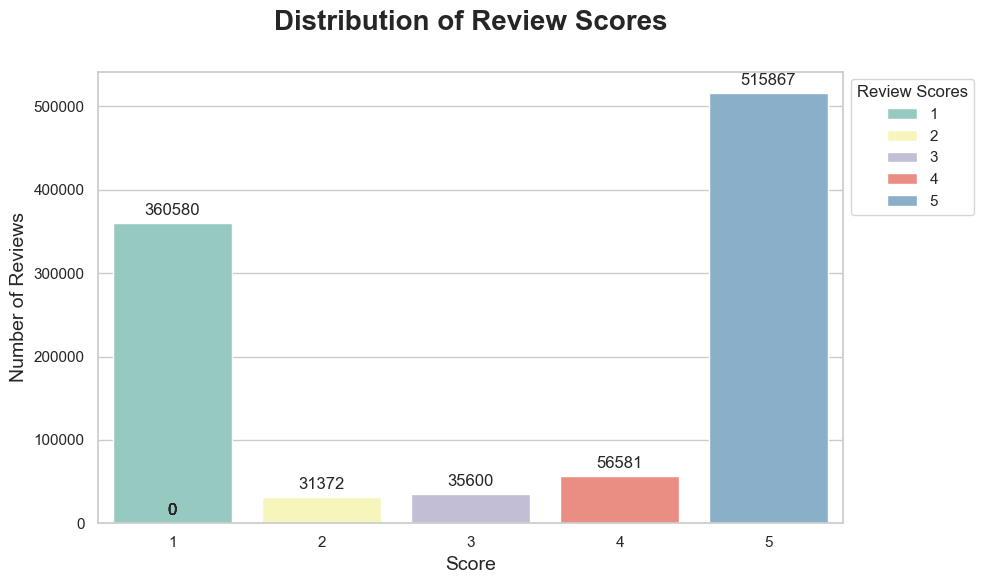

In [47]:
# Setup gaya visualisasi
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))

# Membuat barplot menggunakan seaborn
ax = sns.barplot(
    x=df_count.index, 
    y=df_count['count'], 
    palette="Set3", 
    hue=df_count.index, 
    legend=True
)

# Kustomisasi judul dan label sumbu
plt.title('Distribution of Review Scores', fontsize=20, fontweight='bold', pad=30)
plt.xlabel('Score', fontsize=14)
plt.ylabel('Number of Reviews', fontsize=14)

# Menambahkan anotasi angka di atas bar secara otomatis
for p in ax.patches:
    ax.annotate(
        format(p.get_height(), '.0f'), 
        (p.get_x() + p.get_width() / 2., p.get_height()), 
        ha='center', va='center', 
        xytext=(0, 9), 
        textcoords='offset points',
        fontsize=12
    )

# Konfigurasi legend
plt.legend(title='Review Scores', loc='upper left', bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.show()

In [ ]:
# Convert kolom 'at' menjadi objek datetime
df['at'] = pd.to_datetime(df['at'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 11 columns):
 #   Column                Non-Null Count    Dtype         
---  ------                --------------    -----         
 0   reviewId              1000000 non-null  object        
 1   userName              1000000 non-null  object        
 2   userImage             1000000 non-null  object        
 3   content               999955 non-null   object        
 4   score                 1000000 non-null  int64         
 5   thumbsUpCount         1000000 non-null  int64         
 6   reviewCreatedVersion  750089 non-null   object        
 7   at                    1000000 non-null  datetime64[ns]
 8   replyContent          797 non-null      object        
 9   repliedAt             797 non-null      datetime64[ns]
 10  appVersion            750089 non-null   object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 83.9+ MB


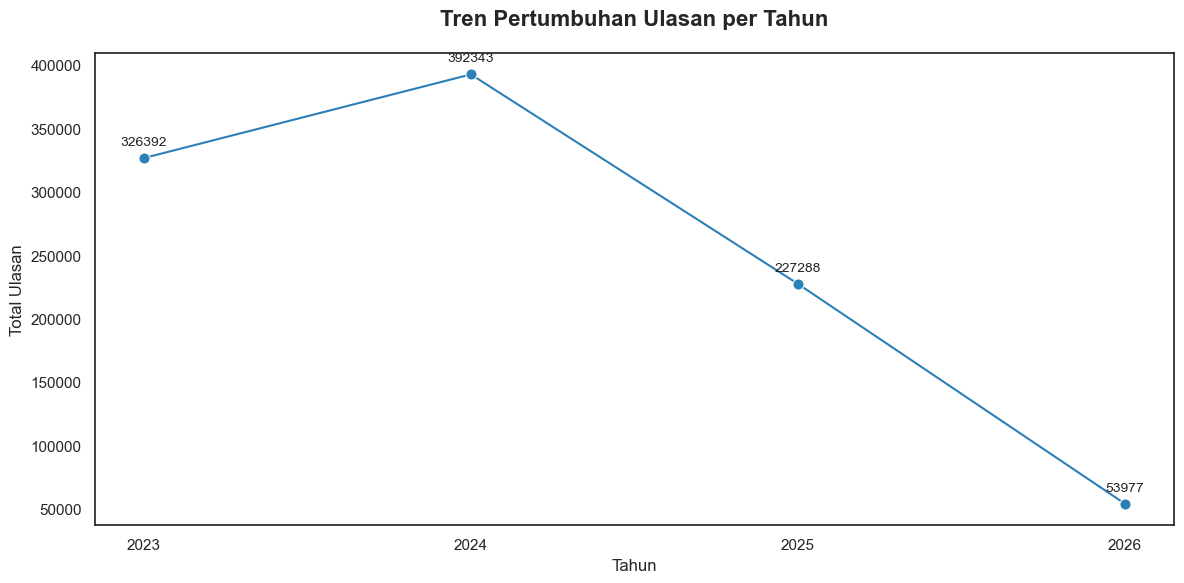

In [50]:
# 1. Pemrosesan Data
df['year'] = df['at'].dt.year
year_trend = df['year'].value_counts().sort_index()

# 2. Inisialisasi Visualisasi
plt.figure(figsize=(12, 6))
sns.set_style("white")

# 3. Membuat Line Plot
# Menggunakan warna teal yang lebih profesional dan linewidth yang lebih tegas
ax = sns.lineplot(
    x=year_trend.index, 
    y=year_trend.values, 
    marker='o', 
    markersize=8, 
    linewidth=1.5, 
    color='#2c7fb8'
)

# 4. Solusi Sumbu X: Memaksa skala sumbu X menjadi bilangan bulat
ax.xaxis.set_major_locator(MaxNLocator(integer=True))

# 5. Fine-tuning Estetika
plt.title('Tren Pertumbuhan Ulasan per Tahun', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Tahun', fontsize=12)
plt.ylabel('Total Ulasan', fontsize=12)

# Menambahkan label angka di atas setiap marker (opsional, untuk kejelasan data)
for x, y in zip(year_trend.index, year_trend.values):
    plt.text(x, y + (max(year_trend.values) * 0.02), f'{int(y)}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

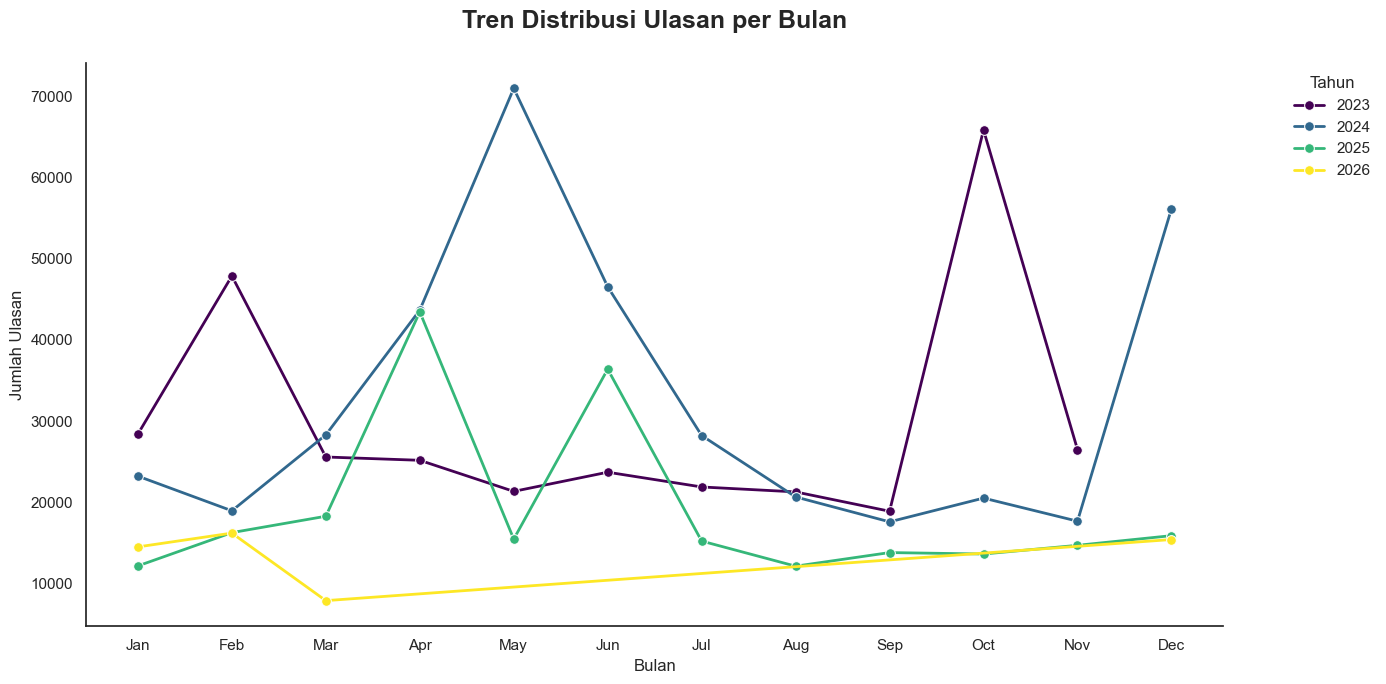

In [52]:

# 1. Pemrosesan Data & Mapping Nama Bulan
df['month'] = df['at'].dt.month
reviews_per_month = df.groupby(['year', 'month']).size().reset_index(name='count')

# Mengubah angka bulan menjadi nama bulan (Jan, Feb, dst) agar lebih informatif
reviews_per_month['month_name'] = reviews_per_month['month'].apply(lambda x: calendar.month_abbr[x])

# 2. Inisialisasi Desain
plt.figure(figsize=(14, 7))
sns.set_style("white") # Menghapus grid latar belakang sesuai preferensi sebelumnya

# 3. Membuat Line Plot
# Menggunakan palette 'viridis' atau 'tab10' agar perbedaan tahun terlihat kontras
ax = sns.lineplot(
    data=reviews_per_month, 
    x='month_name', 
    y='count', 
    hue='year', 
    marker='o', 
    markersize=7,
    linewidth=2,
    palette='viridis' 
)

# 4. Fine-tuning Estetika
plt.title('Tren Distribusi Ulasan per Bulan', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Bulan', fontsize=12)
plt.ylabel('Jumlah Ulasan', fontsize=12)

# Menghapus garis bingkai (spines)
sns.despine()

# Mengatur posisi legend agar tidak menutupi garis
plt.legend(title='Tahun', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

# Memastikan urutan bulan di sumbu X tetap kronologis (Jan -> Dec)
month_order = [calendar.month_abbr[i] for i in range(1, 13)]
ax.set_xticks(range(len(month_order)))
ax.set_xticklabels(month_order)

plt.tight_layout()
plt.show()

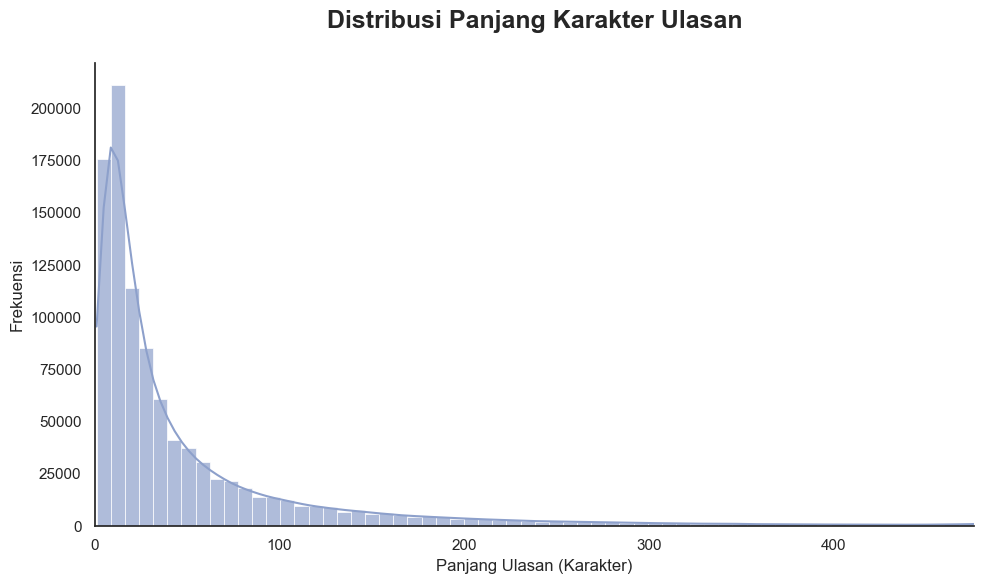


Summary Statistik Panjang Ulasan:
------------------------------
count    1000000.00
mean          55.81
std           84.69
min            1.00
25%           10.00
50%           23.00
75%           61.00
max          766.00
Name: review_length, dtype: object


In [53]:
# 1. Kalkulasi Data
df['review_length'] = df['content'].astype(str).map(len)

# 2. Inisialisasi Visualisasi
sns.set_style("white")
plt.figure(figsize=(10, 6))

# 3. Plotting Histogram & KDE
# Menggunakan warna solid dari palet Set2 agar visual tetap konsisten
color_hex = sns.color_palette("Set2")[2]
sns.histplot(
    df['review_length'],
    bins=100,
    kde=True,
    color=color_hex,
    edgecolor='white',
    alpha=0.7
)

# 4. Optimasi Sumbu & Batasan (Limit pada persentil 99 untuk membuang outliers)
plt.xlim(0, df['review_length'].quantile(0.99))

# 5. Konfigurasi Estetika
plt.title('Distribusi Panjang Karakter Ulasan', fontsize=18, fontweight='bold', pad=25)
plt.xlabel('Panjang Ulasan (Karakter)', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)

# Menghapus bingkai atas dan kanan
sns.despine()

plt.tight_layout()
plt.show()

# 6. Output Statistik Deskriptif
print(f"\nSummary Statistik Panjang Ulasan:\n{'-'*30}")
print(df['review_length'].describe().apply(lambda x: f"{x:.2f}"))

### Text Processing

In [56]:
# Buat Sentiment Polarity dan Subjectivity
df['sentiment_polarity'] = df['content'].apply(lambda x: TextBlob(str(x)).sentiment.polarity)
df['sentiment_subjectivity'] = df['content'].apply(lambda x: TextBlob(str(x)).sentiment.subjectivity)

df[['content', 'sentiment_polarity', 'sentiment_subjectivity']].head()

,content,sentiment_polarity,sentiment_subjectivity
0,iloveit that's it,0.000000,0.000000
1,may team is very nood pls ban them,0.200000,0.300000
2,Just focus on releasing skins and no existing ...,0.058333,0.758333
3,good gamee for holiday,0.700000,0.600000
4,this game is good bro pls monton add some whit...,0.150000,0.500000


In [62]:
#sentiment label dari rating
df['sentiment_rating'] = df['score'].apply(
    lambda x: 'Negative' if x < 2 else ('Positive' if x == 5 else 'Neutral'))

df[['score', 'sentiment_rating']].head()

,score,sentiment_rating
0,5,Positive
1,1,Negative
2,1,Negative
3,5,Positive
4,5,Positive


In [63]:
print(df[['content', 'sentiment_polarity', 'sentiment_subjectivity', 'sentiment_rating']].head())
print(df['sentiment_rating'].value_counts())

                                             content  sentiment_polarity  \
0                                  iloveit that's it            0.000000   
1                 may team is very nood pls ban them            0.200000   
2  Just focus on releasing skins and no existing ...            0.058333   
3                             good gamee for holiday            0.700000   
4  this game is good bro pls monton add some whit...            0.150000   

   sentiment_subjectivity sentiment_rating  
0                0.000000         Positive  
1                0.300000         Negative  
2                0.758333         Negative  
3                0.600000         Positive  
4                0.500000         Positive  
sentiment_rating
Positive    515867
Negative    360580
Neutral     123553
Name: count, dtype: int64


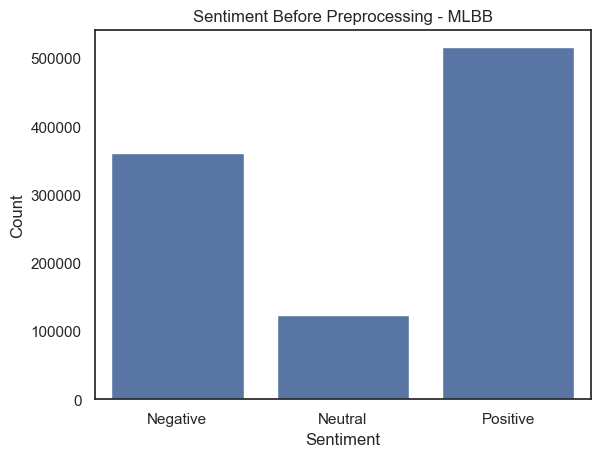

In [64]:
#countplot
sns.countplot(x='sentiment_rating', data=df, order=['Negative', 'Neutral', 'Positive'])
plt.title('Sentiment Before Preprocessing - MLBB')
plt.xlabel('Sentiment')
plt.ylabel('Count')
plt.show()

c:\Users\isan40\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


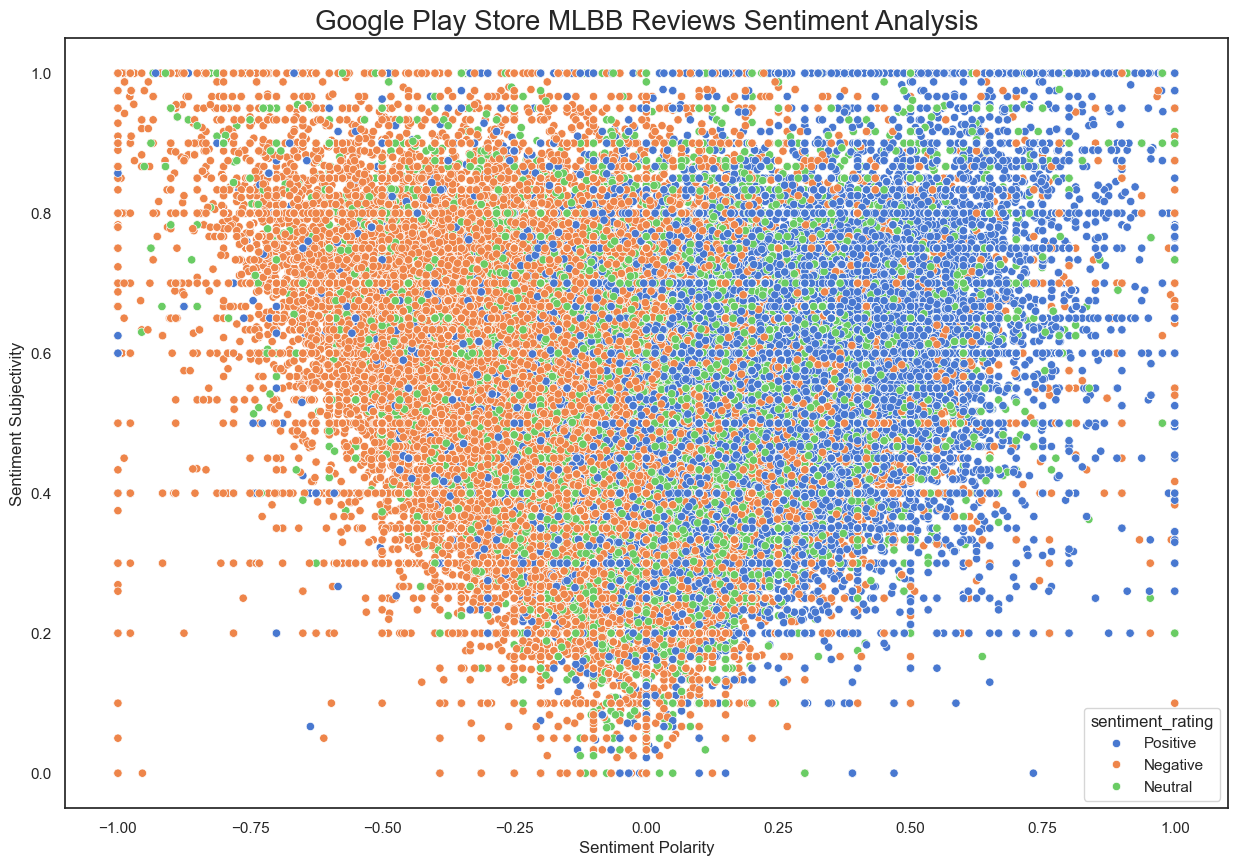

In [66]:
#liat persebaran sentiment
plt.figure(figsize=(15, 10))
sns.scatterplot(
    x=df['sentiment_polarity'],
    y=df['sentiment_subjectivity'],
    hue=df['sentiment_rating'],
    edgecolor='white',
    palette='muted'
)

plt.title("Google Play Store MLBB Reviews Sentiment Analysis", fontsize=20)
plt.xlabel("Sentiment Polarity")
plt.ylabel("Sentiment Subjectivity")
plt.show()